## 1 - GET/CHECK DATA
Below is a sample of the data. It's a set of chat logs from League of Legends (LOL) games and their details.

In [1]:
import pandas as pd

df = pd.read_csv("/content/lol_logs.csv")
pd.set_option('display.max_columns', None)
print(df.head())

   Unnamed: 0              message association_to_offender      time  \
0           0           gold 2 zed                   enemy  00:00:21   
1           1                 IIII                   enemy  00:00:27   
2           2  nice premade lie :o                   enemy  00:00:27   
3           3                  ISI                   enemy  00:00:28   
4           4        smiteless pls                   enemy  00:00:43   

   case_total_reports  allied_report_count  enemy_report_count  \
0                   8                    0                   2   
1                   8                    0                   2   
2                   8                    0                   2   
3                   8                    0                   2   
4                   8                    0                   2   

  most_common_report_reason  chatlog_id champion_name  
0         Negative Attitude           1          Udyr  
1         Negative Attitude           1         Riven  
2 

## 2 - PREPROCESS, (1/11) REMOVE DEAD COLUMNS
I removed an corrupted id column, it had no use anyways.

In [2]:
COLS_TO_REMOVE = [
    "Unnamed: 0"
]
print(f"Number of Columns Before Dropping: {df.shape[1]}")
df.drop(COLS_TO_REMOVE, axis=1, inplace=True)
print(f"Number of Columns After Dropping: {df.shape[1]}")

Number of Columns Before Dropping: 10
Number of Columns After Dropping: 9


## 2 - PREPROCESS, (2/11) REMOVE DEAD ROWS
I removed inappropriate name rows because it's not part of my target.

In [3]:
print(df['most_common_report_reason'].value_counts())
df = df[df['most_common_report_reason'] != 'Inappropriate Name']
print("\nInappropriate name rows now removed.")

most_common_report_reason
Verbal Abuse            570122
Negative Attitude       482139
Offensive Language      420474
Assisting Enemy Team    191461
Spamming                 28341
Inappropriate Name        4685
Name: count, dtype: int64

Inappropriate name rows now removed.


## 2 - PREPROCESS, (3/11) REMOVE ROWS WITH NULL ENTRIES
Rows with null entries were only a small percantage of the entire dataset so I just removed them.

In [4]:
print(f"Number of rows before drop {df.shape[0]}\n")
print(f"Number of incomplete rows by columns:\n{df.isnull().sum()}\n")
df.dropna(inplace=True)
print(f"Number of rows after drop {df.shape[0]}")

Number of rows before drop 1692537

Number of incomplete rows by columns:
message                       29
association_to_offender      104
time                           0
case_total_reports             0
allied_report_count            0
enemy_report_count             0
most_common_report_reason      0
chatlog_id                     0
champion_name                104
dtype: int64

Number of rows after drop 1692404


## 2 - PREPROCESS, (4/11) FEATURE MODIFY
There's a column 'chatlog_id' that doesn't hold value. However, by taking the count of ids by session I can get the amount of dialogue which may be valuable.

In [5]:
df["back_forth_count"] = df["chatlog_id"].map(df['chatlog_id'].value_counts())
df.drop("chatlog_id", axis=1, inplace=True)
print("Replaced 'chatlog_id' with occurences in chat session.")

Replaced 'chatlog_id' with occurences in chat session.


## 2 - PREPROCESS, (5/11) FEATURE MODIFY AGAIN
The 'time' column is formatted by human standards. I change it to just seconds so it's a single integer that the machine can read.

In [6]:
from datetime import datetime

def get_seconds(time):
    t = datetime.strptime(time, "%H:%M:%S")
    return t.hour*3600 + t.minute*60 + t.second

df["time"] = df["time"].apply(get_seconds)
print(df["time"].head())

0    21
1    27
2    27
3    28
4    43
Name: time, dtype: int64


## 2 - PREPROCESS, (6/11) REMOVE OUTLIERS
Removing extreme outliers are important as they can over shoot values for predictions.

In [7]:
# NO OUTLIERS REMOVED FOR RANDOM FOREST

## 2 - PREPROCESS, (7/11) ENCODE CATEGORICALS
Columns with strings are unreadable by machines so we must convert them to numbers. We will just every unique entry into a number like (red-0, green-1, blue-2). We shouldn't use th is for linear models, but from random-tree it's fine.

In [8]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "association_to_offender",
    "champion_name"
]

le = LabelEncoder()
df[categorical_cols[0]] = le.fit_transform(df[categorical_cols[0]])
df["champ_encoded"] = le.fit_transform(df[categorical_cols[1]])

print("Categories encoded.")

Categories encoded.


## 2 - PREPROCESS, (8/11) ENCODE CATEGORICALS AGAIN
I encoded the target, reported reason, a different way. I just numbered the values 1 - 5 by severity. It's messy how machines would handle the ordered labels, that's why the previous one-hot method is preferred, but we'll see.

In [9]:
severity_encode = {
    'Assisting Enemy Team': 5,
    'Verbal Abuse': 4,
    'Offensive Language': 3,
    'Negative Attitude': 2,
    'Spamming': 1
}
df['most_common_report_reason'] = df['most_common_report_reason'].map(severity_encode)
print("Reasons reported encoded.")

Reasons reported encoded.


## 2 - PREPROCESS, (9/11) ENCODE CHATS
As mentioned, machines can't really read text so we will convert the chats to numbers with vaderSentiment. Normally, you would clean text like lower casing then remove punctuation then lemmatize word, but because lol chats casing, punctations, and acronyms carry meaning we will use a special encoder. The vaderSentiment is created specifically for this purposes, being trained on social media and able to present positivity/negativity. Source: https://github.com/cjhutto/vaderSentiment

In [10]:
#!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = df.copy() # APPARENTLY MY DATAFRAME IS HIGHLY FRAGMENTED
analyzer = SentimentIntensityAnalyzer()

def get_toxicity_grade(chat):
    return analyzer.polarity_scores(chat)["compound"]

df["toxicity_grade"] = df["message"].apply(get_toxicity_grade)

## 2 - PREPROCESS, (10/11) REDUCE DIMENSION
Excessive amount of dimension, especially if there telling similar information like "sun and heat", could confuse the machine. I do not think dim reducing is appropriate for my model because there not many columns and I want to see all the champions' influence on prediction.

In [11]:
# NO DIMENSIONALITY REDUCTION

## 2 - PREPROCESS, (11/11) SCALE NUMERICAL COLUMNS BUT SPLIT TRAIN/TEST FIRST
Number range vary for every column. This can confuse the model because higher numbers could be viewed as more important. I'll scale all number around like 0 and 1 so meaning is still there. I'll split it into train/test sets as the scaling method is different.

In [12]:
# SPLIT INTO TRAIN AND TEST FIRST
from sklearn.model_selection import train_test_split

TARGET_COL = "most_common_report_reason"
SEED = 77

tgt_idx = df.columns.get_loc(TARGET_COL)
X = df.drop(columns=TARGET_COL)
y = df.iloc[:, tgt_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train.drop("message", axis=1, inplace=True)
X_test.drop("message", axis=1, inplace=True)

X_train.drop("champion_name", axis=1, inplace=True)
X_test.drop("champion_name", axis=1, inplace=True)

X_train_vals = X_train.values
X_test_vals = X_test.values

y_train_vals = y_train.values
y_test_vals = y_test.values

In [13]:
# NO NUMERICAL SCALING FOR RANDOM FOREST

## 3 - TRAIN MODEL
We will use logistic regression as our model. It can classify multiclasses like severity.

In [14]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=10)
clf.fit(X_train_vals, y_train_vals)

RandomForestClassifier(n_estimators=10)

## 4 - EVALUATION AND RESULTS

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = clf.predict(X_test_vals)
print(accuracy_score(y_test_vals, y_pred))
print(precision_score(y_test_vals, y_pred, average="weighted"))
print(recall_score(y_test_vals, y_pred, average="weighted"))
print(f1_score(y_test_vals, y_pred, average="weighted"))

0.9133097574162213
0.9140920240963244
0.9133097574162213
0.9131747224591654


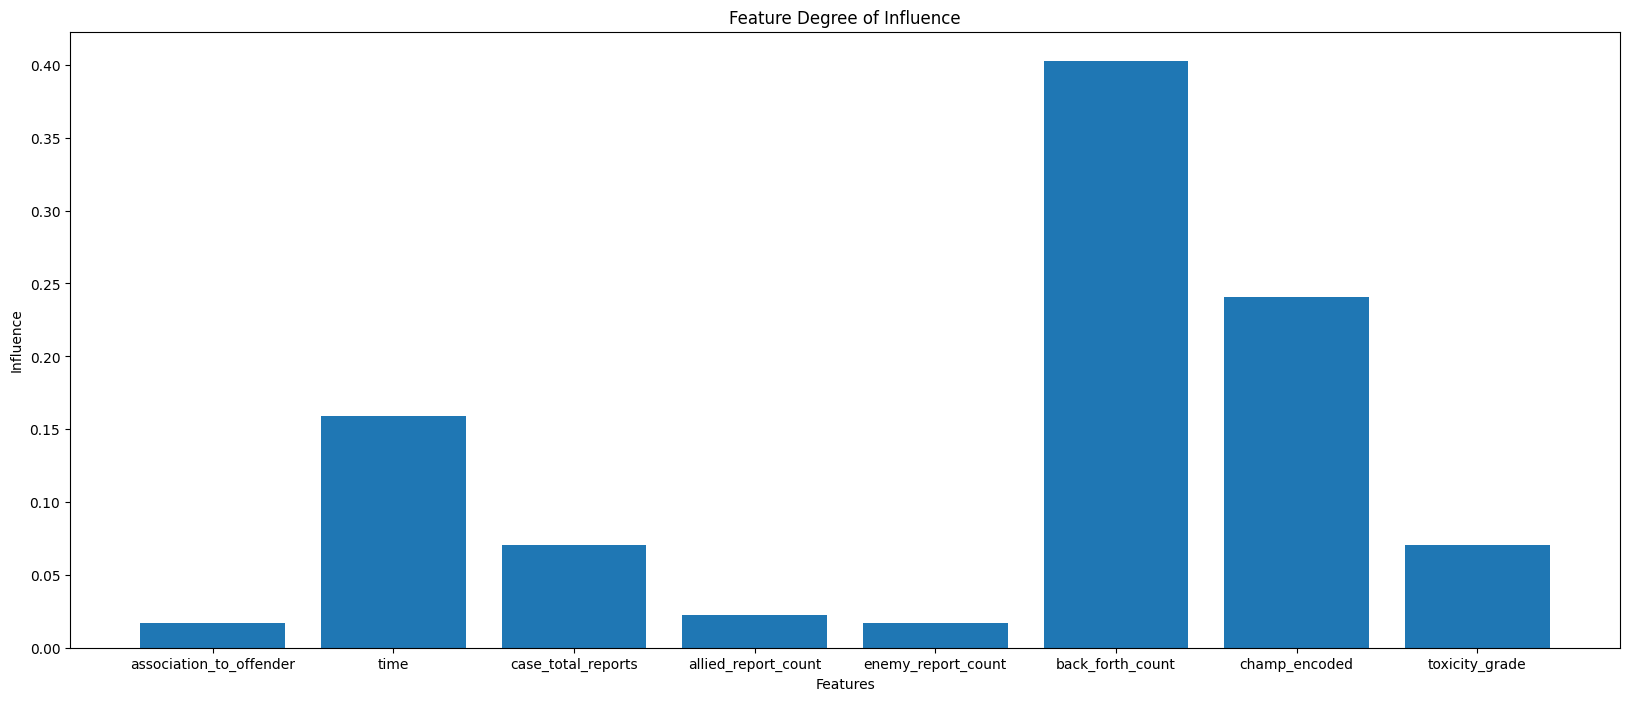

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
plt.bar(range(X_train.shape[1]), clf.feature_importances_)
plt.xticks(range(X_train.shape[1]), X_train.columns.values)
plt.title('Feature Degree of Influence')
plt.xlabel('Features')
plt.ylabel('Influence')
plt.show()

In [16]:
# JUST SOME FUN STATS

pd.set_option('display.max_colwidth', None)
most_pos = df.sort_values(by='toxicity_grade', ascending=False).head(7)
print(most_pos[['message', 'toxicity_grade']])

most_toxic = df.sort_values(by='toxicity_grade', ascending=True).head(7)
print(most_toxic[['message', 'toxicity_grade']])

                                                                                 message  \
927262                             gg gg gg gg gg gg gg gg gg gg gg gg gg gg gg gg gg gg   
48826                 shyvana ? can you help bot ? :) :) :) :) :) play jungle :) :) :) ?   
334442                                       yes yes yes yes yes yes yes yes yes yes yes   
1524265                                        yeees yes yes yes yes yes yes yes yes yes   
552509   but its pretty funny how everyone's like "ohh pls, dont rage - we can win this"   
1137960                 lol but im pretty sure we would win even with renagr trolling :D   
1308375    guys doint lose faith :D we all win in farm so let´s stay positive and win :D   

         toxicity_grade  
927262           0.9843  
48826            0.9811  
334442           0.9792  
1524265          0.9750  
552509           0.9717  
1137960          0.9678  
1308375          0.9667  
                                                       

In [17]:
champ_toxicity = df.groupby('champion_name')['toxicity_grade'].mean()

print("Most Positive")
print(champ_toxicity.sort_values(ascending=False).head(7))

print("Most Toxic")
print(champ_toxicity.sort_values(ascending=True).head(7))

Most Positive
champion_name
Viktor          0.060803
Heimerdinger    0.059251
Zilean          0.056566
Fiora           0.055952
Singed          0.054820
Maokai          0.052925
Xerath          0.052865
Name: toxicity_grade, dtype: float64
Most Toxic
champion_name
Sion        0.018257
Vayne       0.030377
Tristana    0.032101
Draven      0.032383
Caitlyn     0.033678
Zed         0.033716
Skarner     0.034130
Name: toxicity_grade, dtype: float64
